In [1]:
# Jupyter/Colab setup. When this notebook is opened outside a repository
# checkout, clone the project and install its runtime dependencies.
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

REPOSITORY_URL = "https://github.com/hassonlab/podcast-benchmark.git"
IN_COLAB = "google.colab" in sys.modules
start_dir = Path.cwd().resolve()
repo_root = next(
    (
        candidate
        for candidate in (start_dir, *start_dir.parents)
        if (candidate / "pyproject.toml").exists()
    ),
    start_dir,
)

if not (repo_root / "pyproject.toml").exists():
    clone_root = Path("/content") if IN_COLAB else repo_root
    candidate = clone_root / "podcast-benchmark"
    if not candidate.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", REPOSITORY_URL, str(candidate)],
            check=True,
        )
    repo_root = candidate.resolve()

if IN_COLAB or importlib.util.find_spec("core") is None:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-e", str(repo_root)],
        check=True,
    )

os.chdir(repo_root)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Using the podcast-benchmark repository checkout.")


Using the podcast-benchmark repository checkout.


In [2]:
import sys
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from core import registry
from core.config import (
    DataParams,
    ExperimentConfig,
    ModelSpec,
    TaskConfig,
    TrainingParams,
)
from main import run_benchmark
from tasks.sentence_onset import SentenceOnsetConfig
from utils.plot_utils import plot_lag_results

try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)


# Your first NeuroCast Benchmark model

This tutorial follows the same path as a full experiment—**neural data →
preprocessor → registered model → cross-validated lag sweep**—with settings
chosen to finish quickly on a CPU.

You will decode whether a word begins a sentence from one participant's
high-gamma ECoG activity. The only model-specific work is registering a
preprocessor and a small PyTorch model. One `run_benchmark(config)` call then
handles data loading, lagged windows, folds, training, metrics, checkpoints,
and result files.

To open this notebook locally:

```bash
pip install -e ".[tutorial]"
marimo edit tutorials/getting_started.py
```

In [3]:
# Set this to False to reuse a complete Podcast dataset already on disk.
USE_DEMO_DATA = True
EXISTING_DATA_ROOT = repo_root / "data"

print(
    "Demo mode will download subject 8 (~265 MB)."
    if USE_DEMO_DATA
    else f"Using existing data at {EXISTING_DATA_ROOT}."
)


Demo mode will download subject 8 (~265 MB).


In [4]:
demo_relative_path = Path(
    "derivatives/ecogprep/sub-08/ieeg/"
    "sub-08_task-podcast_desc-highgamma_ieeg.fif"
)
demo_url = (
    "https://s3.amazonaws.com/openneuro.org/ds005574/"
    f"{demo_relative_path.as_posix()}"
)
demo_expected_bytes = 265_460_998

def ensure_demo_data(destination_root):
    destination_root = Path(destination_root)
    destination = destination_root / demo_relative_path
    if destination.exists() and destination.stat().st_size == demo_expected_bytes:
        return destination, False

    destination.parent.mkdir(parents=True, exist_ok=True)
    partial = destination.with_suffix(destination.suffix + ".part")
    partial.unlink(missing_ok=True)
    try:
        urllib.request.urlretrieve(demo_url, partial)
        actual_bytes = partial.stat().st_size
        if actual_bytes != demo_expected_bytes:
            raise RuntimeError(
                "Demo download was incomplete: "
                f"expected {demo_expected_bytes:,} bytes, got {actual_bytes:,}."
            )
        partial.replace(destination)
    except Exception:
        partial.unlink(missing_ok=True)
        raise
    return destination, True

In [5]:
if USE_DEMO_DATA:
    data_root = repo_root / ".cache" / "tutorial_data"
    demo_file, downloaded = ensure_demo_data(data_root)
    action = "Downloaded" if downloaded else "Found"
    print(
        f"{action} {demo_file.relative_to(repo_root)} "
        f"({demo_expected_bytes / 1_000_000:.1f} MB)."
    )
else:
    data_root = Path(EXISTING_DATA_ROOT).expanduser().resolve()
    expected_file = data_root / (
        "derivatives/ecogprep/sub-08/ieeg/"
        "sub-08_task-podcast_desc-highgamma_ieeg.fif"
    )
    if not expected_file.exists():
        raise FileNotFoundError(
            "Subject 8 high-gamma data was not found under the selected root: "
            f"{expected_file}"
        )
    print("Using the configured existing dataset.")


Found .cache/tutorial_data/derivatives/ecogprep/sub-08/ieeg/sub-08_task-podcast_desc-highgamma_ieeg.fif (265.5 MB).


## 2. Define and register the model

Registry decorators are the benchmark's extension surface. The preprocessor
below averages each neural window over time, producing one feature per
electrode. The decoder is a single logistic-regression layer.

In your own integration, replace these two functions while leaving the runner
and task configuration unchanged.

In [6]:
@registry.register_data_preprocessor("tutorial_temporal_mean")
def tutorial_temporal_mean(data, _params):
    """Convert [events, electrodes, time] windows to electrode features."""
    return np.asarray(data, dtype=np.float32).mean(axis=-1)

class TutorialLinearDecoder(nn.Module):
    def __init__(self, input_channels):
        super().__init__()
        self.linear = nn.Linear(input_channels, 1)

    def forward(self, features):
        probabilities = torch.sigmoid(self.linear(features))
        return probabilities.squeeze(-1)

@registry.register_model_constructor("tutorial_linear_decoder")
def build_tutorial_linear_decoder(model_params):
    return TutorialLinearDecoder(model_params["input_channels"])

In [7]:
config = ExperimentConfig(
    model_spec=ModelSpec(
        constructor_name="tutorial_linear_decoder",
        params={"output_dim": 1},
    ),
    config_setter_name="set_input_channels",
    task_config=TaskConfig(
        task_name="sentence_onset_task",
        data_params=DataParams(
            data_root=str(data_root),
            subject_ids=[8],
            use_high_gamma=True,
            window_width=1.0,
            preprocessing_fn_name="tutorial_temporal_mean",
        ),
        task_specific_config=SentenceOnsetConfig(
            sentence_csv_path=str(
                repo_root / "processed_data" / "all_sentences_podcast.csv"
            ),
            word_csv_path=str(
                repo_root
                / "processed_data"
                / "df_word_onset_with_pos_class.csv"
            ),
            negatives_per_positive=1,
        ),
    ),
    training_params=TrainingParams(
        batch_size=512,
        epochs=20,
        learning_rate=0.05,
        weight_decay=0.001,
        early_stopping_patience=3,
        n_folds=2,
        # np.arange treats max_lag as exclusive, so 1750 includes +1500.
        min_lag=-1500,
        max_lag=1750,
        lag_step_size=250,
        losses=["bce"],
        loss_weights=[1.0],
        metrics=["roc_auc"],
        early_stopping_metric="roc_auc",
        smaller_is_better=False,
        tensorboard_logging=False,
        random_seed=42,
    ),
    trial_name="tutorial_sentence_onset",
    output_dir=str(repo_root / ".cache" / "tutorial_runs" / "results"),
    checkpoint_dir=str(
        repo_root / ".cache" / "tutorial_runs" / "checkpoints"
    ),
    tensorboard_dir=str(
        repo_root / ".cache" / "tutorial_runs" / "event_logs"
    ),
)


In [8]:
# This single call performs data loading, lag slicing, cross-validation,
# training, checkpointing, and metric collection.
benchmark_run = run_benchmark(config)
result_path = Path(benchmark_run.output_dir).relative_to(repo_root)
print(f"Finished. Results were written to {result_path}.")


Loading podcast data for subject 8 (high-gamma)...



=== SENTENCE ONSET DATASET ===
Total examples: 732
Positives: 366
Negatives: 366
Requested negative ratio: 1
Unmatched sentence onsets dropped: 0
Negative sampling capped: False
Time range: 6.59s - 1792.52s
First 10 examples:
       start  target
0   6.592000     1.0
1   8.162000     0.0
2  13.092000     1.0
3  14.142000     0.0
4  17.292000     0.0
5  17.562000     0.0
6  19.052000     1.0
7  21.233928     1.0
8  21.943928     0.0
9  26.193928     1.0


running lag: -1500
Using AdamW optimizer


Lag -1500, Fold 1:   0%|          | 0/20 [00:00<?, ?it/s]

Lag -1500, Fold 1:   0%|          | 0/20 [00:00<?, ?it/s, roc_auc=0.4508, train_bce=0.695, train_roc_auc=0.457, train_loss=0.695, val_bce=0.694, val_roc_auc=0.451, val_loss=0.694]

...

Lag 1500, Fold 2:   0%|          | 0/20 [00:00<?, ?it/s, roc_auc=0.5722, train_bce=0.694, train_roc_auc=0.609, train_loss=0.694, val_bce=0.693, val_roc_auc=0.569, val_loss=0.693]

Lag 1500, Fold 2:   0%|          | 0/20 [00:00<?, ?it/s, roc_auc=0.5722, train_bce=0.693, train_roc_auc=0.614, train_loss=0.693, val_bce=0.693, val_roc_auc=0.571, val_loss=0.693]

Lag 1500, Fold 2:  40%|████      | 8/20 [00:00<00:00, 261.16it/s, roc_auc=0.5722, train_bce=0.693, train_roc_auc=0.614, train_loss=0.693, val_bce=0.693, val_roc_auc=0.571, val_loss=0.693]

Time taken for training loop: 0.03076481819152832

MAIN MODEL CROSS-VALIDATION RESULTS
--- Individual Folds (train_bce) ---
Fold 1: 0.6933
Fold 2: 0.6936
Mean train bce: 0.6935 ± 0.0002

--- Individual Folds (train_roc_auc) ---
Fold 1: 0.5898
Fold 2: 0.6070
Mean train roc_auc: 0.5984 ± 0.0086

--- Individual Folds (val_bce) ---
Fold 1: 0.6933
Fold 2: 0.6936
Mean val bce: 0.6935 ± 0.0002

--- Individual Folds (val_roc_auc) ---
Fold 1: 0.4924
Fold 2: 0.5722
Mean val roc_auc: 0.5323 ± 0.0399

--- Individual Folds (test_bce) ---
Fold 1: 0.6933
Fold 2: 0.6936
Mean test bce: 0.6935 ± 0.0002

--- Individual Folds (test_roc_auc) ---
Fold 1: 0.4554
Fold 2: 0.5227
Mean test roc_auc: 0.4890 ± 0.0337



Finished. Results were written to .cache/tutorial_runs/results/tutorial_sentence_onset_2026-08-02-18-30-21.


,run_unit,lags,test_roc_auc_mean,test_roc_auc_std
0,combined,-1500,0.502871,0.053884
1,combined,-1250,0.479090,0.047046
2,combined,-1000,0.460001,0.020745
3,combined,-750,0.489646,0.002272
4,combined,-500,0.585927,0.017581
5,combined,-250,0.662003,0.015115
6,combined,0,0.733933,0.062333
7,combined,250,0.643072,0.033791
8,combined,500,0.511778,0.022725
9,combined,750,0.527148,0.024224


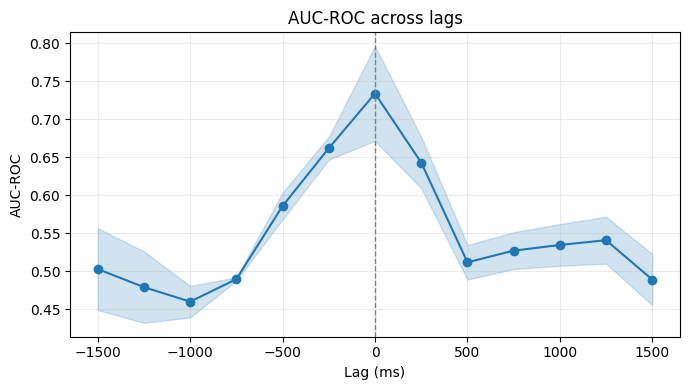

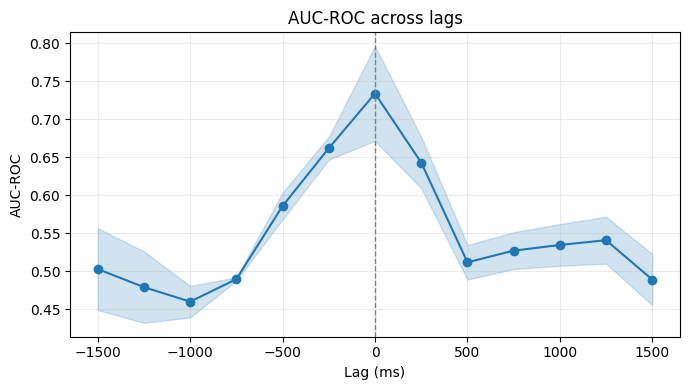

In [9]:
result_columns = [
    column
    for column in [
        "run_unit", "lags", "test_roc_auc_mean", "test_roc_auc_std"
    ]
    if column in benchmark_run.lag_results.columns
]
display(benchmark_run.lag_results[result_columns])
lag_figure, _lag_axes = plot_lag_results(
    benchmark_run.lag_results, metric="test_roc_auc"
)
display(lag_figure)


# Part 2: Bring your own dataset

The task, preprocessor, model, and runner are all independent of the Podcast
dataset. To make that concrete, we will create a tiny synthetic recording with
four ECoG electrodes and register a dataset getter for it.

Sentence onsets occur at reproducibly irregular times. Neural activity follows
a time-warped sinusoid whose peaks are locked to sentence onsets and fall away
smoothly on either side. Noise and different electrode gains keep the example
realistic enough to train while leaving the expected structure easy to see.

In [10]:
synthetic_dataset_name = "tutorial_synthetic_sentence_data"

def make_synthetic_sentence_dataset(
    *, duration_s=180.0, sampling_rate=100.0, n_electrodes=4, seed=7
):
    """Create a Raw recording and canonical sentence-onset label table."""
    rng = np.random.default_rng(seed)
    n_samples = int(duration_s * sampling_rate)
    sample_times = np.arange(n_samples) / sampling_rate

    # Draw irregular word timings, then start sentences after randomly sized
    # groups of words. This makes the sentence periods non-isochronous.
    word_intervals = rng.uniform(0.55, 0.95, size=int(duration_s / 0.55))
    word_onsets = 2.0 + np.cumsum(word_intervals)
    word_onsets = word_onsets[word_onsets < duration_s - 2.0]
    sentence_positions = []
    position = int(rng.integers(4, 9))
    while position < len(word_onsets):
        sentence_positions.append(position)
        position += int(rng.integers(7, 14))

    sentence_mask = np.zeros(len(word_onsets), dtype=bool)
    sentence_mask[sentence_positions] = True
    sentence_onsets = word_onsets[sentence_mask]

    # Place a raised-cosine pulse at each onset. Its width adapts to the
    # neighboring sentence intervals, while remaining narrow enough to
    # produce a clear, symmetric falloff around the onset.
    onset_locked_wave = np.zeros(n_samples, dtype=np.float32)
    sentence_intervals = np.diff(sentence_onsets)
    for onset_index, onset in enumerate(sentence_onsets):
        previous_interval = sentence_intervals[max(onset_index - 1, 0)]
        next_interval = sentence_intervals[min(onset_index, len(sentence_intervals) - 1)]
        half_width = min(1.5, 0.35 * previous_interval, 0.35 * next_interval)
        in_pulse = np.abs(sample_times - onset) <= half_width
        phase = (sample_times[in_pulse] - onset) / half_width
        pulse = 0.5 * (1.0 + np.cos(np.pi * phase))
        onset_locked_wave[in_pulse] = np.maximum(
            onset_locked_wave[in_pulse], pulse.astype(np.float32)
        )

    electrode_gains = np.linspace(1.0, 0.35, n_electrodes, dtype=np.float32)
    noise_uv = rng.normal(0.0, 0.15, size=(n_electrodes, n_samples))
    slow_background = 0.08 * np.sin(2 * np.pi * 0.08 * sample_times)
    data_uv = (
        0.1
        + electrode_gains[:, None] * onset_locked_wave[None, :]
        + slow_background[None, :]
        + noise_uv
    ).astype(np.float32)

    channel_names = [f"SYNTH_ECOG_{index + 1}" for index in range(n_electrodes)]
    info = mne.create_info(
        ch_names=channel_names,
        sfreq=sampling_rate,
        ch_types=["ecog"] * n_electrodes,
    )
    raw = mne.io.RawArray(data_uv * 1e-6, info, verbose=False)
    raw.info["description"] = (
        "Synthetic sentence data: onset-locked sinusoid plus Gaussian noise"
    )

    labels = pd.DataFrame(
        {
            "event_id": [
                f"synthetic_word_{index:04d}"
                for index in range(len(word_onsets))
            ],
            "start": word_onsets,
            "word": [f"word_{index}" for index in range(len(word_onsets))],
            "sentence_onset": sentence_mask,
        }
    )
    return raw, labels, sentence_onsets

@registry.register_dataset(synthetic_dataset_name)
def load_synthetic_sentence_raw(_subject_id, data_params):
    """Load the tutorial FIF and satisfy the benchmark dataset contract."""
    raw_path = Path(data_params.data_root) / data_params.dataset_params["raw_file"]
    if not raw_path.exists():
        raise FileNotFoundError(
            f"Synthetic Raw file not found: {raw_path}. "
            "Click 'Generate synthetic dataset' first."
        )
    return mne.io.read_raw_fif(raw_path, preload=True, verbose=False)

In [11]:
print("Generating the synthetic four-electrode Raw and label table...")


Generating the synthetic four-electrode Raw and label table...


Wrote subject_1_sentence_raw.fif with 4 electrodes and 23 sentence onsets.


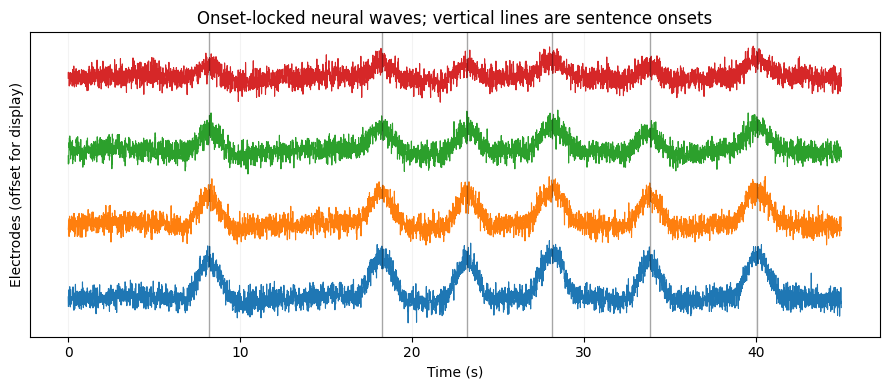

,event_id,start,word,sentence_onset
0,synthetic_word_0000,2.800038,word_0,False
1,synthetic_word_0001,3.708924,word_1,False
2,synthetic_word_0002,4.569198,word_2,False
3,synthetic_word_0003,5.209281,word_3,False
4,synthetic_word_0004,5.879347,word_4,False
5,synthetic_word_0005,6.778769,word_5,False
6,synthetic_word_0006,7.330875,word_6,False
7,synthetic_word_0007,8.209366,word_7,True
8,synthetic_word_0008,9.078194,word_8,False
9,synthetic_word_0009,9.815368,word_9,False


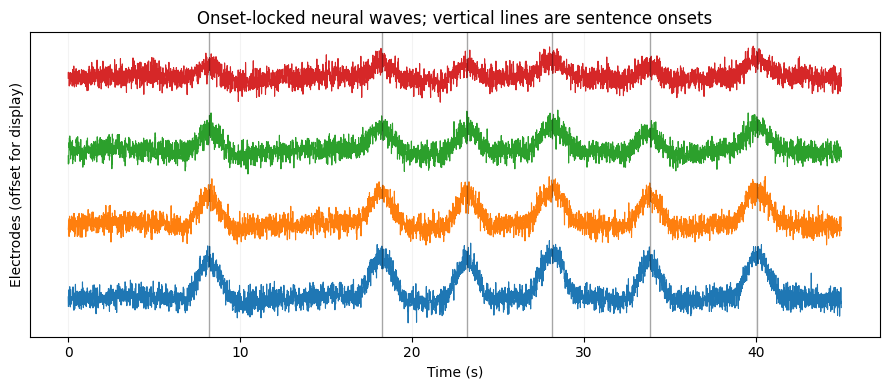

In [12]:
synthetic_data_root = repo_root / ".cache" / "tutorial_synthetic_data"
synthetic_data_root.mkdir(parents=True, exist_ok=True)
synthetic_raw_path = synthetic_data_root / "subject_1_sentence_raw.fif"
synthetic_labels_path = synthetic_data_root / "sentence_labels.csv"

synthetic_raw, synthetic_labels, synthetic_sentence_onsets = (
    make_synthetic_sentence_dataset()
)
synthetic_raw.save(synthetic_raw_path, overwrite=True, verbose=False)
synthetic_labels.to_csv(synthetic_labels_path, index=False)

preview_seconds = 45
preview_samples = int(preview_seconds * synthetic_raw.info["sfreq"])
synthetic_preview, synthetic_axes = plt.subplots(figsize=(9, 4))
preview_times = synthetic_raw.times[:preview_samples]
preview_data_uv = synthetic_raw.get_data(stop=preview_samples) * 1e6
for electrode_index, values in enumerate(preview_data_uv):
    synthetic_axes.plot(
        preview_times,
        values + electrode_index * 1.8,
        linewidth=0.8,
        label=synthetic_raw.ch_names[electrode_index],
    )
for sentence_onset in synthetic_sentence_onsets:
    if sentence_onset <= preview_seconds:
        synthetic_axes.axvline(
            sentence_onset, color="black", alpha=0.35, linewidth=1
        )
synthetic_axes.set(
    xlabel="Time (s)",
    ylabel="Electrodes (offset for display)",
    title="Onset-locked neural waves; vertical lines are sentence onsets",
)
synthetic_axes.set_yticks([])
synthetic_axes.grid(alpha=0.15)
synthetic_preview.tight_layout()

print(
    f"Wrote {synthetic_raw_path.name} with {len(synthetic_raw.ch_names)} "
    f"electrodes and {int(synthetic_labels['sentence_onset'].sum())} "
    "sentence onsets."
)
display(synthetic_preview)
display(synthetic_labels.head(12))


In [13]:
synthetic_config = ExperimentConfig(
    # These are exactly the same registered model and preprocessor used above.
    model_spec=ModelSpec(
        constructor_name="tutorial_linear_decoder",
        params={"output_dim": 1},
    ),
    config_setter_name="set_input_channels",
    task_config=TaskConfig(
        # The task is unchanged; only its canonical label table is different.
        task_name="sentence_onset_task",
        data_params=DataParams(
            dataset_name=synthetic_dataset_name,
            dataset_params={"raw_file": "subject_1_sentence_raw.fif"},
            data_root=str(synthetic_data_root),
            subject_ids=[1],
            use_high_gamma=False,
            signal_unit="uV",
            window_width=1.0,
            preprocessing_fn_name="tutorial_temporal_mean",
        ),
        task_specific_config=SentenceOnsetConfig(
            labels_path=str(synthetic_labels_path),
            negatives_per_positive=1,
        ),
    ),
    training_params=TrainingParams(
        batch_size=128,
        epochs=20,
        learning_rate=0.05,
        weight_decay=0.001,
        early_stopping_patience=3,
        n_folds=2,
        # np.arange treats max_lag as exclusive, so 1750 includes +1500.
        min_lag=-1500,
        max_lag=1750,
        lag_step_size=250,
        losses=["bce"],
        loss_weights=[1.0],
        metrics=["roc_auc"],
        early_stopping_metric="roc_auc",
        smaller_is_better=False,
        tensorboard_logging=False,
        random_seed=42,
    ),
    trial_name="tutorial_synthetic_sentence_onset",
    output_dir=str(repo_root / ".cache" / "tutorial_runs" / "results"),
    checkpoint_dir=str(
        repo_root / ".cache" / "tutorial_runs" / "checkpoints"
    ),
    tensorboard_dir=str(
        repo_root / ".cache" / "tutorial_runs" / "event_logs"
    ),
)


In [14]:
synthetic_benchmark_run = run_benchmark(synthetic_config)
synthetic_result_path = Path(
    synthetic_benchmark_run.output_dir
).relative_to(repo_root)
print(f"Finished. Results were written to {synthetic_result_path}.")


Loading tutorial_synthetic_sentence_data data for subject 1 (broadband)...
  - [Config] Scaling data: Volt -> MicroVolt (x 1e6)

=== SENTENCE ONSET DATASET ===
Total examples: 46
Positives: 23
Negatives: 23
Requested negative ratio: 1
Unmatched sentence onsets dropped: 0
Negative sampling capped: False
Time range: 5.21s - 175.35s
First 10 examples:
       start  target             event_id     word
0   5.209281     0.0  synthetic_word_0003   word_3
1   8.209366     1.0  synthetic_word_0007   word_7
2   9.078194     0.0  synthetic_word_0008   word_8
3  14.051148     0.0  synthetic_word_0015  word_15
4  18.246992     1.0  synthetic_word_0020  word_20
5  23.197247     1.0  synthetic_word_0027  word_27
6  28.160831     1.0  synthetic_word_0034  word_34
7  30.922401     0.0  synthetic_word_0038  word_38
8  33.847274     1.0  synthetic_word_0042  word_42
9  40.087935     1.0  synthetic_word_0050  word_50
running lag: -1500
Using AdamW optimizer


Lag -1500, Fold 1:   0%|          | 0/20 [00:00<?, ?it/s]

Lag -1500, Fold 1:   0%|          | 0/20 [00:00<?, ?it/s, roc_auc=0.6667, train_bce=0.786, train_roc_auc=0.139, train_loss=0.786, val_bce=0.707, val_roc_auc=0.667, val_loss=0.707]

Lag -1500, Fold 1:   0%|          | 0/20 [00:00<?, ?it/s, roc_auc=0.6667, train_bce=0.767, train_roc_auc=0.139, train_loss=0.767, val_bce=0.704, val_roc_auc=0.667, val_loss=0.704]

Lag -1500, Fold 1:   0%|          | 0/20 [00:00<?, ?it/s, roc_auc=0.6667, train_bce=0.751, train_roc_auc=0.139, train_loss=0.751, val_bce=0.703, val_roc_auc=0.667, val_loss=0.703]

...

Lag 1500, Fold 2:   0%|          | 0/20 [00:00<?, ?it/s, roc_auc=0.2500, train_bce=0.698, train_roc_auc=0.557, train_loss=0.698, val_bce=0.706, val_roc_auc=0.25, val_loss=0.706]

Lag 1500, Fold 2:   0%|          | 0/20 [00:00<?, ?it/s, roc_auc=0.2500, train_bce=0.694, train_roc_auc=0.614, train_loss=0.694, val_bce=0.706, val_roc_auc=0.25, val_loss=0.706]

Lag 1500, Fold 2:  15%|█▌        | 3/20 [00:00<00:00, 270.02it/s, roc_auc=0.2500, train_bce=0.694, train_roc_auc=0.614, train_loss=0.694, val_bce=0.706, val_roc_auc=0.25, val_loss=0.706]

Time taken for training loop: 0.011224508285522461

MAIN MODEL CROSS-VALIDATION RESULTS
--- Individual Folds (train_bce) ---
Fold 1: 0.6851
Fold 2: 0.7035
Mean train bce: 0.6943 ± 0.0092

--- Individual Folds (train_roc_auc) ---
Fold 1: 0.6528
Fold 2: 0.5000
Mean train roc_auc: 0.5764 ± 0.0764

--- Individual Folds (val_bce) ---
Fold 1: 0.7363
Fold 2: 0.7063
Mean val bce: 0.7213 ± 0.0150

--- Individual Folds (val_roc_auc) ---
Fold 1: 0.5556
Fold 2: 0.2500
Mean val roc_auc: 0.4028 ± 0.1528

--- Individual Folds (test_bce) ---
Fold 1: 0.6889
Fold 2: 0.6982
Mean test bce: 0.6935 ± 0.0046

--- Individual Folds (test_roc_auc) ---
Fold 1: 0.5606
Fold 2: 0.3636
Mean test roc_auc: 0.4621 ± 0.0985



Finished. Results were written to .cache/tutorial_runs/results/tutorial_synthetic_sentence_onset_2026-08-02-18-30-25.


,run_unit,lags,test_roc_auc_mean,test_roc_auc_std
0,combined,-1500,0.613636,0.143939
1,combined,-1250,0.587121,0.125000
2,combined,-1000,0.787879,0.030303
3,combined,-750,0.640152,0.178030
4,combined,-500,0.946970,0.053030
5,combined,-250,1.000000,0.000000
6,combined,0,1.000000,0.000000
7,combined,250,0.996212,0.003788
8,combined,500,0.969697,0.030303
9,combined,750,0.958333,0.041667


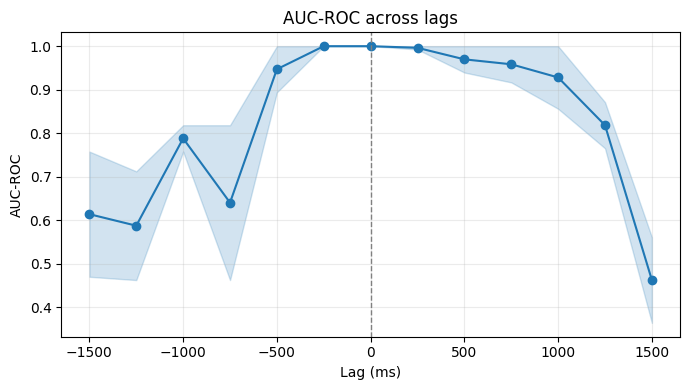

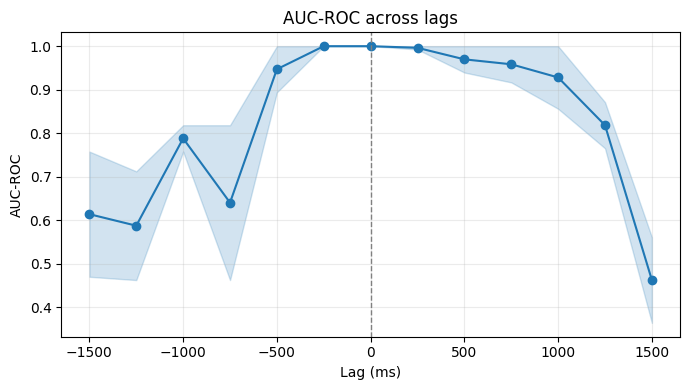

In [15]:
synthetic_result_columns = [
    column
    for column in [
        "run_unit", "lags", "test_roc_auc_mean", "test_roc_auc_std"
    ]
    if column in synthetic_benchmark_run.lag_results.columns
]
display(synthetic_benchmark_run.lag_results[synthetic_result_columns])
synthetic_lag_figure, _synthetic_lag_axes = plot_lag_results(
    synthetic_benchmark_run.lag_results, metric="test_roc_auc"
)
display(synthetic_lag_figure)


## Where to go next

- Increase folds and use a finer lag step in [`docs/configuration.md`](../docs/configuration.md).
- Adapt the registered model and preprocessor using
  [`docs/onboarding-model.md`](../docs/onboarding-model.md). There are more customization options to fit your use case.
- Try another built-in target from [`docs/task-reference.md`](../docs/task-reference.md).
- Add a dataset or task without changing the training loop using the registry
  APIs described in [`docs/api-reference.md`](../docs/api-reference.md).

For a production run, move this `ExperimentConfig` into YAML and invoke
`python main.py --config ...`; the notebook and CLI use the same pipeline.